In [48]:
import math

class Value:
    def __init__(self, data, _children=(), _op="", label=""):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), "+")
        def _backward():
            self.grad = 1.0*out.grad
            other.grad = 1.0*out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), "*")
        def _backward():
            self.grad = other.data * out.grad
            other.grad = self.data * out.grad
        out._backward = _backward
        return out
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self,), "tanh")
        def _backward():
            self.grad = (1 - t**2) * out.grad
        out._backward = _backward
        return out

In [49]:
from graphviz import Digraph


def trace(root):
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root):
    dot = Digraph(format="svg", graph_attr={"rankdir": "LR"})
    nodes, edges = trace(root)

    for n in nodes:
        uid = str(id(n))
        # Value node
        dot.node(
            name=uid,
            label=f"{{ {n.label} | data {n.data:.4f} | grad {n.grad:.4f} }}",
            shape="record",
        )
        # Operation node (if any)
        if n._op:
            op_id = uid + n._op
            dot.node(name=op_id, label=n._op)
            dot.edge(op_id, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

In [24]:
a = Value(5, label="a")
b = Value(-3, label="b")
c = Value(10, label="c")
e = a*b; e.label = "e"
d = c + e; d.label = "d"
f = Value(10, label="f")
L = d*f; L.label = "L"
L.grad = 1.0
d.grad = f.data
f.grad = d.data
c.grad = f.data
e.grad = f.data
a.grad = b.data * e.grad
b.grad = a.data * e.grad
L

Value(data=-50)

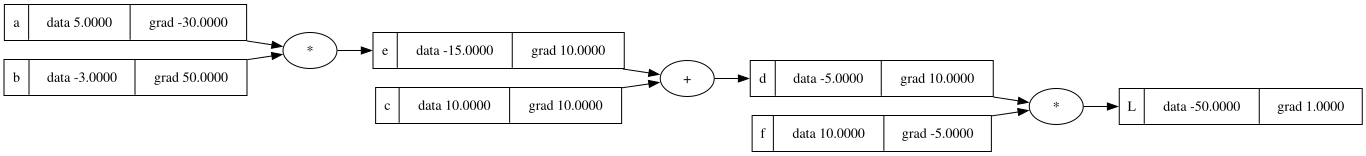

In [27]:
draw_dot(L)

In [26]:
def lol():
    h = 0.0001
    a = Value(5, label="a")
    b = Value(-3, label="b")
    c = Value(10, label="c")
    e = a*b; e.label = "e"
    d = c + e; d.label = "d"
    f = Value(10, label="f")
    L1 = d*f; L1.label = "L"
    
    a = Value(5, label="a")
    b = Value(-3, label="b")
    b.data += h
    c = Value(10, label="c")
    e = a*b; e.label = "e"
    d = c + e; d.label = "d"
    f = Value(10, label="f")
    L2 = d*f; L2.label = "L"   

    return (L2.data-L1.data)/h

lol()

50.000000000096634

In [57]:
# input values
x1 = Value(2.0, label="x1")
x2 = Value(0.0, label="x2")
# weiights
w1 = Value(-3.0, label="w1")
w2 = Value(1.0, label="w2")
# bias
b = Value(6.8813735870195432, label="b")
x1w1 = x1*w1; x1w1.label = "x1*w1"
x2w2 = x2*w2; x2w2.label = "x2*w2"
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = "x1w1+x2w2"
n = x1w1x2w2 + b; n.label = "n"
o = n.tanh(); o.label = "o"



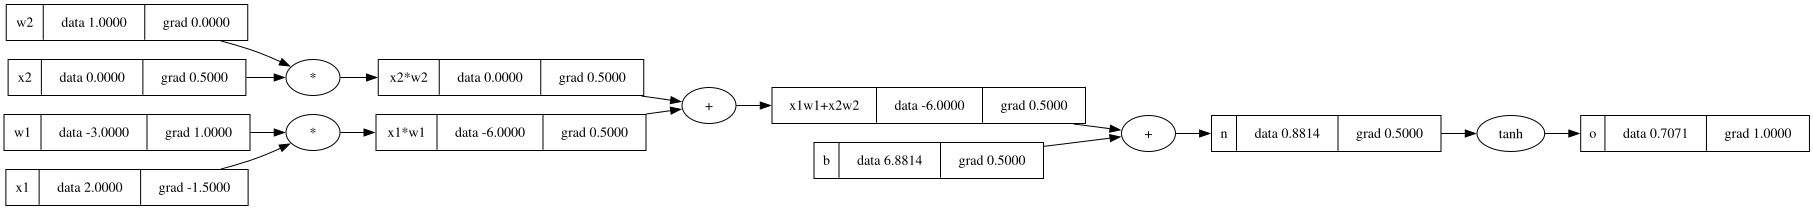

In [63]:
draw_dot(o)

In [67]:
o.grad = 1.0
o._backward()
n._backward()
b._backward()
x1w1x2w2._backward()
x1w1._backward()
x2w2._backward()
w1._backward()
x1._backward()
w2._backward()
x2._backward()

In [ ]:
topo = []
visited = set() # maintains a set of all nodes visited 
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)  # keeps adding children until it reaches the leaf nodes
        topo.append(v) # adds itself after its children

build_topo(o)
topo

[Value(data=6.881373587019543),
 Value(data=2.0),
 Value(data=-3.0),
 Value(data=-6.0),
 Value(data=1.0),
 Value(data=0.0),
 Value(data=0.0),
 Value(data=-6.0),
 Value(data=0.8813735870195432),
 Value(data=0.7071067811865476)]